# GARCH 분석 — 지정학 리스크와 BTC 변동성
## 지정학적 위기 시 비트코인은 디지털 금인가?
### 캡스톤디자인 | 팀명: 분석많이된다

---

## 4가지 모델

| 모델 | 분산 방정식 외생변수 | 목적 |
|---|---|---|
| Model 1 | GPR_zscore (공식 GPR) | 공식 GPR 설명력 |
| Model 2 | GPR_custom (F3_z) | 자체 GPR 설명력 |
| Model 3 | VIX + fear_greed_lag1 | 시장심리 설명력 |
| Model 4 | GPR_custom + VIX + fear_greed_lag1 | 통합 모델 |

## GARCH-X 공식
 | 
```
σ²(t) = ω + α·ε²(t-1) + β·σ²(t-1) + Σ γ_k·X_k(t)

γ > 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↑
γ < 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↓ (안전자산 특성)
```

## 필요 파일

```
master_data.csv
```

---
## Step 0. 라이브러리

In [1]:
!pip install pandas numpy matplotlib scipy arch --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from arch import arch_model
import warnings, os, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_invasion': '2022-02-24',
    'israel_hamas'           : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_invasion': '러-우 전쟁',
    'israel_hamas'           : '이스라엘-하마스',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}

MODEL_EXOG = {
    'Model1': ['GPR_zscore'],
    'Model2': ['GPR_custom'],
    'Model3': ['VIX', 'fear_greed_lag1'],
    'Model4': ['GPR_custom', 'VIX', 'fear_greed_lag1'],
}
MODEL_LABELS = {
    'Model1': 'M1: GPR 공식',
    'Model2': 'M2: GPR_custom',
    'Model3': 'M3: VIX+F&G',
    'Model4': 'M4: 통합모델',
}
MODEL_COLORS = {
    'Model1': '#E76F51',
    'Model2': '#2A9D8F',
    'Model3': '#457B9D',
    'Model4': '#8338EC',
}

print('✅ 환경 설정 완료')

✅ 환경 설정 완료


---
## Step 1. master_data.csv 로드

In [3]:
if not os.path.exists('master_data.csv'):
    raise FileNotFoundError('master_data.csv 없음')

master = pd.read_csv('master_data.csv')
master['date'] = pd.to_datetime(master['date'])

num_cols = ['BTC','Gold','TLT','DXY','SP500','NASDAQ',
            'GPR_custom','GPR','GPR_zscore',
            'VIX','fear_greed','fear_greed_lag1']
for col in num_cols:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

print(f'✅ master_data: {len(master)}행')
print(f'   기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
print(f'\n이벤트별 거래일:')
print(master.groupby('event_name')['date'].count().to_string())
print(f'\n결측치:')
print(master[num_cols].isnull().sum().to_string())

✅ master_data: 216행
   기간: 2019-05-20 ~ 2026-03-26

이벤트별 거래일:
event_name
hormuz_crisis              34
israel_hamas               38
israel_iran                37
russia_ukraine_invasion    35
soleimani_assassination    34
us_israel_iran             38

결측치:
BTC                0
Gold               0
TLT                0
DXY                0
SP500              0
NASDAQ             0
GPR_custom         0
GPR                0
GPR_zscore         0
VIX                0
fear_greed         0
fear_greed_lag1    6


---
## Step 2. 데이터 준비

- BTC 수익률 × 100 — GARCH 수렴 안정화
- 외생변수 Z-score 표준화 — 계수 크기 비교 가능

In [4]:
# 2. 이벤트 순서 정렬
order = list(EVENT_DATES.keys())
master['_order'] = master['event_name'].map({ev:i for i,ev in enumerate(order)})
master_sorted = master.sort_values(['_order','date']).reset_index(drop=True)

# 3. [핵심 수정] 결측치 제거 (0으로 채우지 않고 정직하게 행 삭제)
# 외생변수와 BTC 수익률이 모두 존재하는 '진짜' 데이터만 남깁니다.
exog_cols_all = ['GPR_custom', 'GPR_zscore', 'VIX', 'fear_greed_lag1']
master_final = master_sorted.dropna(subset=['BTC'] + exog_cols_all).copy()

# 4. BTC 수익률 100배 (GARCH 수렴도 향상)
master_final['returns_pct'] = master_final['BTC'] * 100

# 5. [핵심 수정] 인덱스 일치를 위해 데이터프레임 내에서 표준화 수행
for col in exog_cols_all:
    mu, sig = master_final[col].mean(), master_final[col].std()
    master_final[f'{col}_scaled'] = (master_final[col] - mu) / sig

# 6. GARCH 입력용 최종 변수 추출
final_returns = master_final['returns_pct']
final_exog = master_final[[f'{col}_scaled' for col in exog_cols_all]]

print(f'✅ 분석 대상: {len(master_final)}거래일 (결측치 제거 완료)')
print(f'\nBTC 수익률 기술통계 (×100):')
print(final_returns.describe().round(4))

print(f'\n외생변수 표준화 결과 (mean=0, std=1 점검):')
print(final_exog.describe().loc[['mean', 'std']].round(4))

✅ 분석 대상: 210거래일 (결측치 제거 완료)

BTC 수익률 기술통계 (×100):
count    210.0000
mean       0.2450
std        3.5067
min      -15.2334
25%       -1.3438
50%       -0.0176
75%        1.9493
max       13.5764
Name: returns_pct, dtype: float64

외생변수 표준화 결과 (mean=0, std=1 점검):
      GPR_custom_scaled  GPR_zscore_scaled  VIX_scaled  fear_greed_lag1_scaled
mean                0.0               -0.0        -0.0                     0.0
std                 1.0                1.0         1.0                     1.0


---
## Step 3. GARCH(1,1)-X 4모델 추정

GARCH 는 어제 변동성이 오늘에도 영향을 줄 것이라는 논리고, 
ARCH가 어제 사건이 터진 정도, GARCH가 어제 얼마나 변동이 컸는가

이때 외생변수 GPR을 이용하여, 오늘의 변동성이 어제 변동성 + 어제의 전쟁 지수가 더 크게 변동하게 만들려는 것인지 파악하려는 것

------

그래서

- MODEL1: GPR 공식 지수 이용 : 기존 전쟁 지수가 영향을 주는가?
- MODEL2: GPR 커스텀 지수 이용 : 우리가 커스텀한 값이 가장 영향 주는가?
- MODEL3: VIX(공포지수) + 탐욕지수 : 전쟁 말고, 그냥 공포 심리가 가장 영향 주는가?
- MODEL4: 전쟁 + 공포 + 탐욕 : 전쟁과 일반 공포가 가장 영향 주는가?
- MODEL4: 전쟁 + 공포 + 탐욕 : 커스텀 전쟁과 일반 공포가 가장 영향 주는가?

-----
다만 ARCH는 외생변수를 넣고, 돌리는 것이 불가능(미지원 기능임)
-> 커스텀 방식 사용

In [19]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln

# ── 모델별 외생변수 정의 ──────────────────────────────────────────
MODEL_EXOG = {
    'Model1': ['GPR_zscore_scaled'],           # 공식 전쟁 지수의 영향력만 단독 측정
    'Model2': ['GPR_custom_scaled'],           # 커스텀 전쟁 지수의 영향력만 단독 측정
    'Model3': ['VIX_scaled', 'fear_greed_lag1_scaled'], # 전쟁 빼고 시장 심리(공포/탐욕)만 측정
    'Model4': ['GPR_zscore_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'], # 공식 전쟁 + 시장 심리 통합
    'Model5': ['GPR_custom_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'], # 커스텀 전쟁 + 시장 심리 통합 (필살기)
}

# ── GARCH-X 핵심 함수 ────────────────────────────────────────────
def run_garch_x_volatility(y_series, exog_df, model_exog_cols, model_name="Model"):
    """
    변동성 방정식에 외생변수(t-1 lag)를 포함하는 GARCH-X
    h_t = omega + alpha * e_{t-1}^2 + beta * h_{t-1} + gamma @ x_{t-1}
    
    핵심 아이디어:
    - x_{t-1} 을 사용 → "어제의 전쟁/공포 지수가 오늘 변동성에 영향"
    - arch 라이브러리 미지원으로 직접 MLE 구현
    """

    # 1) 컬럼 매칭 (scaled 우선, 없으면 원본)
    actual_cols = []
    for c in model_exog_cols:
        scaled = f"{c}_scaled"
        if scaled in exog_df.columns:
            actual_cols.append(scaled)
        elif c in exog_df.columns:
            actual_cols.append(c)
        else:
            print(f"  ⚠️  [{model_name}] 컬럼 '{c}' 없음 → 스킵")

    print(f"\n[{model_name}] 사용 외생변수: {actual_cols}")

    # 2) 데이터 준비
    y = y_series.dropna().astype(np.float64)
    
    if not actual_cols:
        print("  → 외생변수 없음: 기본 GARCH(1,1) 실행")
        from arch import arch_model
        am = arch_model(y, vol='Garch', p=1, q=1, dist='studentst', mean='Constant')
        res = am.fit(disp='off', show_warning=False)
        return {
            'result': res, 'params': None, 'exog_cols': [],
            'aic': res.aic, 'bic': res.bic, 'loglik': res.loglikelihood,
            'converged': res.convergence_flag == 0, 'error': None,
            'param_names': None
        }

    X_raw = exog_df.loc[y.index, actual_cols].fillna(method='ffill').fillna(0).astype(np.float64)

    # ★ 핵심: t-1 lag 적용 → "어제 외생변수가 오늘 변동성에 영향"
    X_lag = X_raw.shift(1).fillna(0).values  # shape: (T, K)

    y_vals = y.values
    T = len(y_vals)
    K = len(actual_cols)

    # 3) Log-Likelihood 정의
    def neg_loglik(params):
        """
        params 구조: [mu, omega, alpha, beta, gamma_0...gamma_{K-1}, nu]
        변동성 방정식: h_t = omega + alpha*e_{t-1}^2 + beta*h_{t-1} + gamma @ x_{t-1}
        """
        mu    = params[0]
        omega = params[1]
        alpha = params[2]
        beta  = params[3]
        gamma = params[4:4+K]
        nu    = params[4+K]

        # 제약 조건
        if omega <= 0 or alpha < 0 or beta < 0:
            return 1e10
        if alpha + beta >= 0.9999:
            return 1e10
        if nu <= 2.01:
            return 1e10

        e = y_vals - mu
        h = np.empty(T)
        h[0] = np.var(e)  # 초기 분산

        for t in range(1, T):
            exog_effect = np.dot(gamma, X_lag[t])  # 어제 외생변수 효과
            h[t] = omega + alpha * e[t-1]**2 + beta * h[t-1] + exog_effect
            if h[t] <= 1e-8:
                h[t] = 1e-8

        # Standardized Student-t log-likelihood
        log_lik = (
            gammaln((nu + 1) / 2)
            - gammaln(nu / 2)
            - 0.5 * np.log(np.pi * (nu - 2))
            - 0.5 * np.log(h)
            - ((nu + 1) / 2) * np.log(1 + e**2 / ((nu - 2) * h))
        )

        return -np.sum(log_lik)

    # 4) 최적화
    # 초기값: [mu, omega, alpha, beta, gamma*K, nu]
    init_params = [np.mean(y_vals),
                   np.var(y_vals) * 0.05,
                   0.08,
                   0.88] + [0.001] * K + [5.0]

    bounds = (
        [(None, None)]        # mu: 제한 없음
        + [(1e-6, None)]      # omega: 양수
        + [(1e-6, 0.5)]       # alpha: 0~0.5
        + [(0.3,  0.999)]     # beta: 지속성 보장
        + [(None, None)] * K  # gamma: 부호 제한 없음 (음수도 허용)
        + [(2.01, 50.0)]      # nu: 자유도
    )

    try:
        opt = minimize(
            neg_loglik, init_params,
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': 5000, 'ftol': 1e-14, 'gtol': 1e-8}
        )

        p = opt.x
        n_params = len(p)
        loglik = -opt.fun
        aic = -2 * loglik + 2 * n_params
        bic = -2 * loglik + n_params * np.log(T)

        # 파라미터 이름 정리
        param_names = ['mu', 'omega', 'alpha', 'beta'] + \
                      [f'gamma({c})' for c in actual_cols] + ['nu']

        # 5) 결과 출력
        print(f"\n  {'─'*50}")
        print(f"  ▶ [{model_name}] 추정 결과")
        print(f"  {'─'*50}")
        print(f"  {'파라미터':<20} {'추정값':>10}")
        print(f"  {'─'*50}")
        for name, val in zip(param_names, p):
            print(f"  {name:<20} {val:>10.4f}")
        print(f"  {'─'*50}")
        print(f"  LogLikelihood : {loglik:.4f}")
        print(f"  AIC           : {aic:.4f}")
        print(f"  BIC           : {bic:.4f}")
        print(f"  수렴 여부     : {'✅ 성공' if opt.success else '⚠️ 미수렴'}")
        print(f"  alpha+beta    : {p[2]+p[3]:.4f}  ← 1에 가까울수록 변동성 지속")

        # gamma 방향 해석
        print(f"\n  ▶ 외생변수 효과 해석:")
        for i, c in enumerate(actual_cols):
            g = p[4+i]
            direction = "↑ 변동성 증가" if g > 0 else "↓ 변동성 감소"
            significance = "★ 유의" if abs(g) > 0.001 else "  (미미)"
            print(f"    gamma({c}) = {g:.4f}  →  {direction} {significance}")

        return {
    'result'     : opt,
    'neg_loglik' : neg_loglik,   # ← 추가: Hessian 계산에 필요
    'T'          : T,            # ← 추가: 자유도 계산에 필요
    'params'     : dict(zip(param_names, p)),
    'exog_cols'  : actual_cols,
    'aic'        : aic,
    'bic'        : bic,
    'loglik'     : loglik,
    'converged'  : opt.success,
    'error'      : None,
    'param_names': param_names,
}

    except Exception as e:
        print(f"  ❌ [{model_name}] 오류: {e}")
        return {
            'result': None, 'params': None, 'exog_cols': actual_cols,
            'converged': False, 'error': str(e)
        }


# ── 실행 ─────────────────────────────────────────────────────────
garch_results = {}
print('=' * 60)
print('▶ GARCH(1,1)-X 변동성 분석 (직접 MLE | t-1 외생변수)')
print('=' * 60)

for mname, exog_cols in MODEL_EXOG.items():
    res = run_garch_x_volatility(
        master_final['returns_pct'],
        master_final,
        exog_cols,
        model_name=mname
    )
    garch_results[mname] = res


# ── 모델 비교 요약 ────────────────────────────────────────────────
print('\n' + '=' * 60)
print('▶ 모델 비교 요약')
print('=' * 60)
print(f"{'모델':<10} {'LogLik':>10} {'AIC':>10} {'BIC':>10} {'수렴':>6}")
print('-' * 60)

for mname, res in garch_results.items():
    if res.get('error') is None and res.get('aic') is not None:
        conv = '✅' if res['converged'] else '⚠️'
        print(f"{mname:<10} {res['loglik']:>10.3f} {res['aic']:>10.3f} {res['bic']:>10.3f} {conv:>6}")

print('-' * 60)
best = min(
    [(k, v) for k, v in garch_results.items() if v.get('aic') is not None],
    key=lambda x: x[1]['aic']
)
print(f"  → AIC 기준 최적 모델: {best[0]}")

▶ GARCH(1,1)-X 변동성 분석 (직접 MLE | t-1 외생변수)

[Model1] 사용 외생변수: ['GPR_zscore_scaled']

  ──────────────────────────────────────────────────
  ▶ [Model1] 추정 결과
  ──────────────────────────────────────────────────
  파라미터                        추정값
  ──────────────────────────────────────────────────
  mu                       0.1589
  omega                    0.2976
  alpha                    0.0000
  beta                     0.9760
  gamma(GPR_zscore_scaled)    -0.3143
  nu                       3.3040
  ──────────────────────────────────────────────────
  LogLikelihood : -539.4294
  AIC           : 1090.8588
  BIC           : 1110.9415
  수렴 여부     : ✅ 성공
  alpha+beta    : 0.9760  ← 1에 가까울수록 변동성 지속

  ▶ 외생변수 효과 해석:
    gamma(GPR_zscore_scaled) = -0.3143  →  ↓ 변동성 감소 ★ 유의

[Model2] 사용 외생변수: ['GPR_custom_scaled']

  ──────────────────────────────────────────────────
  ▶ [Model2] 추정 결과
  ──────────────────────────────────────────────────
  파라미터                        추정값
  ───────────────────

**AIC 기준 모델 적합도 순위**

AIC = -2 × log-likelihood + 2 × 파라미터 수 : 아카이케 정보 기준 모델 비교 지표로
        - -2 × log-likelihood : 모델이 데이터를 얼마나 잘 설명하는지로(낮을수록 좋음)
        - 2 × 파라미터 수 : 모델이 얼마나 복잡한가(페널티임)
        - AIC는 낮을수록 좋은 모델

BIC = -2 × LogLik + ln(n) × k :  변수 하나 추가할 때 AIC보다 2.7배 더 가혹하게 패널티 부여
BIC는 관측치 수까지 반영해서 패널티가 더 강함.

------

| 순위 | 모델 | AIC | 핵심 변수 | 
|---|---|---|---|
| 1 | Model2 | 1087.05 | GPR_custom 단독 | 
| 2 | Model3 | 1087.67 | VIX + 탐욕 | 
| 3 | Model5 | 1088.47 | GPR_custom + VIX + 탐욕 | 
| 4 | Model4 | 1088.49 | GPR_공식 + VIX + 탐욕 |
| 5 | Model1 | 1090.86 | GPR_공식 단독 | 

-> BIC 값도 순위 동일

-----
**결과 해석**

- 공식 GPR이 오히려 변동성을 낮추고, 커스텀 GPR이 변동성을 4배 이상 올림
- model2는 alpha+beta가 0.3737로 낮게 나왔는데, 이건 변동성이 과거의 기억에 의존하기보단 전쟁 뉴스 gamma라는 외부 변수에 의해 실시간으로 결정되는 성향되는 매우 강하다는 것

----
위 코드 한계점

1.  최적화 수렴의 불안정성 (Local Optima)scipy.optimize.minimize는 초기값에 따라 결과가 달라질 수 있는 국소 최적해(Local Optima) 문제에 취약합니다.
    - 문제점: 특히 Model 2에서 alpha는 0.07인데 beta가 0.3으로 뚝 떨어졌습니다. 보통 금융 시계열에서 beta는 0.7~0.9 사이가 일반적입니다.
    - 한계점: 비트코인의 변동성이 워낙 파괴적이라 그럴 수도 있지만, 최적화 알고리즘이 전역 최적해(Global Optima)를 찾지 못하고 중간에 멈췄을 가능성도 배제할 수 없습니다.

2. 변동성 비대칭성(Asymmetry) 미반영현재 모델은 일반적인 GARCH(1,1) 구조입니다.
   - 문제점: 비트코인은 가격이 폭락할 때 변동성이 커지는 경향(지렛대 효과, Leverage Effect)이 강합니다
   - 한계점: 호재로 인한 상승 변동성과 악재로 인한 하락 변동성을 구분하지 못하므로, "전쟁 뉴스"가 하락장과 상승장에서 어떻게 다르게 작용하는지 정밀하게 포착하지 못합니다. (이를 위해서는 GJR-GARCH나 EGARCH 모델이 필요합니다.)

3. 외생변수의 선형성 가정현재 공식은 gamma * GPR 형태로, 전쟁 지수와 변동성이 직선(선형) 관계로 비례한다고 가정합니다.
    - 문제점: 현실에서는 전쟁 지수가 일정 수준(임계치)을 넘어야만 시장이 반응할 수 있습니다.
    - 한계점: 지수가 낮을 때는 반응이 없다가 특정 수준에서만 폭발하는 비선형적 반응을 잡아내기엔 모델이 너무 단순할 수 있습니다.



---
그래서 위의 한계점 3가지를 개선하거나, 연구의 한계 및 향후 과제로 쓰던가 둘 중에 하나로 이용

---
## Step 4. 계수 및 유의성 확인

In [20]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import t as t_dist

def compute_pvalues(opt_result, neg_loglik_func, param_names, T, K):
    """
    최적화 결과에서 표준오차, t-통계량, p-value 계산
    
    opt_result : scipy minimize 결과
    neg_loglik_func : 음의 로그우도 함수
    param_names : 파라미터 이름 리스트
    T : 관측치 수
    K : 외생변수 수
    """
    params = opt_result.x
    n_params = len(params)

    # ── 1. Hessian 수치 계산 ──────────────────────────────────
    eps = 1e-5  # 미분 간격
    H = np.zeros((n_params, n_params))

    for i in range(n_params):
        for j in range(n_params):
            # 중앙차분법으로 2차 편미분 근사
            p_pp = params.copy(); p_pp[i] += eps; p_pp[j] += eps
            p_pm = params.copy(); p_pm[i] += eps; p_pm[j] -= eps
            p_mp = params.copy(); p_mp[i] -= eps; p_mp[j] += eps
            p_mm = params.copy(); p_mm[i] -= eps; p_mm[j] -= eps

            H[i, j] = (
                neg_loglik_func(p_pp) - neg_loglik_func(p_pm)
                - neg_loglik_func(p_mp) + neg_loglik_func(p_mm)
            ) / (4 * eps ** 2)

    # ── 2. 분산-공분산 행렬 = H^{-1} ─────────────────────────
    try:
        cov_matrix = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        print("⚠️ Hessian 역행렬 계산 실패 → 유사역행렬 사용")
        cov_matrix = np.linalg.pinv(H)

    # ── 3. 표준오차, t-통계량, p-value ───────────────────────
    se = np.sqrt(np.abs(np.diag(cov_matrix)))  # 표준오차
    t_stats = params / se                        # t-통계량
    df = T - n_params                            # 자유도
    p_values = 2 * (1 - t_dist.cdf(np.abs(t_stats), df=df))  # 양측검정

    # ── 4. 결과 출력 ──────────────────────────────────────────
    print(f"\n  {'파라미터':<28} {'추정값':>8} {'SE':>8} {'t-stat':>8} {'p-value':>10} {'유의성':>6}")
    print(f"  {'─'*72}")

    for name, val, s, t, p in zip(param_names, params, se, t_stats, p_values):
        # 유의성 표시
        if p < 0.01:
            sig = '***'
        elif p < 0.05:
            sig = '**'
        elif p < 0.1:
            sig = '*'
        else:
            sig = ''

        print(f"  {name:<28} {val:>8.4f} {s:>8.4f} {t:>8.3f} {p:>10.4f} {sig:>6}")

    print(f"\n  유의성: *** p<0.01  ** p<0.05  * p<0.1")

    return {
        'se'      : se,
        't_stats' : t_stats,
        'p_values': p_values,
        'cov_mat' : cov_matrix,
    }


# ── 실행: 각 모델에 적용 ──────────────────────────────────────────
for mname, res in garch_results.items():
    if res.get('error') is not None or res.get('result') is None:
        continue

    print(f"\n{'='*72}")
    print(f"  [{mname}] p-value 검정")
    print(f"{'='*72}")

    # neg_loglik 함수를 모델별로 다시 클로저로 묶어야 함
    # → run_garch_x_volatility 안에서 neg_loglik을 return에 추가하거나
    #   아래처럼 results에 저장해두세요 (아래 수정 참고)

    stat = compute_pvalues(
        opt_result      = res['result'],
        neg_loglik_func = res['neg_loglik'],   # ← 함수 저장 필요 (아래 수정)
        param_names     = res['param_names'],
        T               = res['T'],
        K               = len(res['exog_cols'])
    )
    garch_results[mname]['stats'] = stat


  [Model1] p-value 검정

  파라미터                              추정값       SE   t-stat    p-value    유의성
  ────────────────────────────────────────────────────────────────────────
  mu                             0.1589   0.1857    0.855     0.3934       
  omega                          0.2976   0.1788    1.664     0.0976      *
  alpha                          0.0000   0.0000 5000.000     0.0000    ***
  beta                           0.9760   0.0119   82.155     0.0000    ***
  gamma(GPR_zscore_scaled)      -0.3143   0.1789   -1.757     0.0804      *
  nu                             3.3040   0.7297    4.528     0.0000    ***

  유의성: *** p<0.01  ** p<0.05  * p<0.1

  [Model2] p-value 검정

  파라미터                              추정값       SE   t-stat    p-value    유의성
  ────────────────────────────────────────────────────────────────────────
  mu                             0.0778   0.1840    0.423     0.6728       
  omega                          9.4822   6.4757    1.464     0.1447       
  a

**결과 정리**

p-value를 garch 모델을 수정하면서 Hessian을 이용한 수치 미분 코드를 구현한 p-value 뽑음
다만, 
5개 모델 중 어떤 외생변수도 p<0.05 수준에서 통계적으로 유의하게 변동성에 영향을 준다고 말할 순 없음

----
1) Model 2 (커스텀 지수): 영향력은 크지만, 불확실성도 큼
커스텀 GPR이 변동성에 영향을 줄 것 같긴 한데,
 데이터가 부족해서 우연일 가능성을 배제할 수 없다


2) Model 1 (공식 지수): 공식 GPR이 오르면 변동성 감소/ gamma는 음수이지만, p-value는 10퍼에서 유의함

3) 공통 현상: alpha=0
-> alpha=0이 진짜 경제적 현상인지, 수치 오류인지 구분이 필요

----
현재 한계점
1) 샘플 사이즈의 한계: GARCH 모델은 수치적으로 매우 불안정해서 보통 수천 개의 데이터(Daily 데이터 기준 5~10년치)가 필요함. 분석 기간이 짧아서 표준오차가 커져 p-value가 유의하게 나오지 않을 확률이 높음

2) 수치 미분 오차: 직접 짠 eps = 1e-5를 이용한 중앙 차분법은 근사치라서, eps가 너무 크거나 작으면 Hessian 게산이 흔들려서 SE가 실제보다 크게 나올 수 있음

3) 국소 최적해 문제도 있음: model2의 beta가 0.3인 것이 가짜 정답에 빠졌을 확률도 존재함

---
일단 AIC 기준으로는 Model 2이 제일 낫다는 건 변하지 않아서, p-value가 아쉬우면 
지정학적 리스크(커스텀 지수)는 비트코인 변동성의 가장 강력한 설명 변수(AIC 최저)이나, 반응의 변동폭이 커서 통계적 유의성은 추후 더 긴 시계열 데이터를 통해 보완이 필요함

In [21]:
gamma_rows = []
print('\n▶ 외생변수 γ 계수 요약\n')
print(f'{"모델":<10} {"변수":<28} {"γ":>10} {"p-value":>10} {"유의":<12} {"해석"}')
print('-' * 85)

for mname, res in garch_results.items():
    # 오류 또는 결과 없는 모델 스킵
    if res.get('error') or res.get('result') is None:
        continue
    if res.get('stats') is None:
        print(f'{mname:<10} ⚠️ p-value 미계산 (compute_pvalues 먼저 실행 필요)')
        continue

    param_names = res['param_names']   # ['mu','omega','alpha','beta','gamma(...)','nu']
    params_dict = res['params']        # {'mu': 0.15, ...}
    p_values    = res['stats']['p_values']  # numpy array, param_names 순서와 동일

    # gamma 파라미터만 추출
    for i, pname in enumerate(param_names):
        if not pname.startswith('gamma('):
            continue

        # 변수명 추출: 'gamma(GPR_custom_scaled)' → 'GPR_custom_scaled'
        vname = pname[6:-1]
        coef  = params_dict[pname]
        pv    = p_values[i]

        # 유의성 판정
        if pv < 0.05:
            sig = '✅ p<0.05'
        elif pv < 0.10:
            sig = '△ p<0.10'
        else:
            sig = '— 비유의'

        # 해석
        if coef > 0 and pv < 0.05:
            interp = '변동성 증가'
        elif coef < 0 and pv < 0.05:
            interp = '변동성 감소'
        elif coef > 0 and pv < 0.10:
            interp = '변동성 증가 경향'
        elif coef < 0 and pv < 0.10:
            interp = '변동성 감소 경향'
        else:
            interp = '비유의'

        print(f'{mname:<10} {vname:<28} {coef:>10.5f} {pv:>10.4f} {sig:<12} {interp}')

        gamma_rows.append({
            '모델'   : mname,
            '변수'   : vname,
            'γ'      : round(coef, 5),
            'p-value': round(pv, 4),
            '유의'   : sig,
            '해석'   : interp
        })

gamma_df = pd.DataFrame(gamma_rows)
print('\n')
print(gamma_df.to_string(index=False))


▶ 외생변수 γ 계수 요약

모델         변수                                    γ    p-value 유의           해석
-------------------------------------------------------------------------------------
Model1     GPR_zscore_scaled              -0.31429     0.0804 △ p<0.10     변동성 감소 경향
Model2     GPR_custom_scaled               4.00116     0.1921 — 비유의        비유의
Model3     VIX_scaled                     -0.04868     0.8191 — 비유의        비유의
Model3     fear_greed_lag1_scaled          0.48311     0.1462 — 비유의        비유의
Model4     GPR_zscore_scaled               0.17779     0.2226 — 비유의        비유의
Model4     VIX_scaled                     -0.23089     0.3357 — 비유의        비유의
Model4     fear_greed_lag1_scaled          0.39808     0.1181 — 비유의        비유의
Model5     GPR_custom_scaled               0.24943     0.1805 — 비유의        비유의
Model5     VIX_scaled                     -0.12599     0.6598 — 비유의        비유의
Model5     fear_greed_lag1_scaled          0.33811     0.3233 — 비유의        비유의


    모델               

**결과 정리**

통계적으로 확실히 유의한 외생변수는 없음. 그나마 공식 GPR만 10% 수준에서 경향성 존재


1) Model1 — GPR 공식지수 (γ = -0.314, p=0.08) △
유일하게 10% 수준 경향성이 있는데 방향이 음수입니다. 공식 GPR이 오르면 변동성이 줄어든다는 것
-> 공식 GPR은 전 세계 지정학 리스크를 뭉뚱그려서 측정하기 때문에 방산주에 특화된 신호가 희석된 결과

2) Model2 — GPR 커스텀지수 (γ = +4.00, p=0.19) —
방향은 맞고 크기도 제일 크지만 p=0.19로 비유의입니다. SE가 3.06으로 추정 불확실성이 너무 커서 생긴 문제입니다. 데이터가 더 있었으면 유의했을 가능성이 높습니다.


3) Model3 — VIX + 탐욕지수 (p=0.82, p=0.15) —
둘 다 완전 비유의입니다. VIX는 p=0.82로 사실상 설명력 없음. 탐욕지수도 방향은 양수(+)로 맞지만 유의하지 않습니다.


4) Model4, 5 — 복합 모델 전부 비유의
변수를 여러 개 넣었더니 오히려 서로 효과를 잡아먹어서 전부 비유의로 떨어졌습니다. 다중공선성 문제입니다


----
다 비유의 나온 이유ㅜ

1. 데이터 210개 → GARCH는 최소 300~500개 필요
2. 커스텀 MLE 수치 미분 → SE가 실제보다 부풀려짐
3. 복합 모델 → 변수끼리 효과 상쇄

---
## Step 5. 모델 비교 (AIC / BIC)

In [23]:
# MODEL_LABELS 없으면 위에 추가
MODEL_LABELS = {
    'Model1': 'GPR 공식지수 단독',
    'Model2': 'GPR 커스텀지수 단독',
    'Model3': 'VIX + 탐욕지수',
    'Model4': 'GPR 공식 + VIX + 탐욕',
    'Model5': 'GPR 커스텀 + VIX + 탐욕',
}

rows = []
for mname, res in garch_results.items():
    # 커스텀 MLE는 res['result']가 scipy OptimizeResult라
    # None 체크만 하면 됨 (error 키 확인)
    if res.get('error') or res.get('aic') is None:
        continue

    rows.append({
        '모델'    : mname,
        '설명'    : MODEL_LABELS.get(mname, mname),
        '외생변수': ', '.join(res['exog_cols']),
        'AIC'     : round(res['aic'], 3),
        'BIC'     : round(res['bic'], 3),
        'Log-Lik' : round(res['loglik'], 3),
        '수렴'    : '✅' if res.get('converged') else '⚠️',
    })

compare_df = (pd.DataFrame(rows)
                .set_index('모델')
                .sort_values('AIC'))

print('▶ 모델 비교 (AIC 오름차순):\n')
display(compare_df)

best = compare_df.index[0]
print(f'\n✅ 최적 모델: {best}')
print(f'   설명     : {compare_df.loc[best, "설명"]}')
print(f'   AIC      : {compare_df.loc[best, "AIC"]}')
print(f'   BIC      : {compare_df.loc[best, "BIC"]}')
print(f'   외생변수 : {compare_df.loc[best, "외생변수"]}')

▶ 모델 비교 (AIC 오름차순):



,설명,외생변수,AIC,BIC,Log-Lik,수렴
모델,,,,,,
Model2,GPR 커스텀지수 단독,GPR_custom_scaled,1087.050,1107.132,-537.525,✅
Model3,VIX + 탐욕지수,"VIX_scaled, fear_greed_lag1_scaled",1087.667,1111.097,-536.833,✅
Model5,GPR 커스텀 + VIX + 탐욕,"GPR_custom_scaled, VIX_scaled, fear_greed_lag1...",1088.474,1115.251,-536.237,✅
Model4,GPR 공식 + VIX + 탐욕,"GPR_zscore_scaled, VIX_scaled, fear_greed_lag1...",1088.489,1115.266,-536.244,✅
Model1,GPR 공식지수 단독,GPR_zscore_scaled,1090.859,1110.941,-539.429,✅



✅ 최적 모델: Model2
   설명     : GPR 커스텀지수 단독
   AIC      : 1087.05
   BIC      : 1107.132
   외생변수 : GPR_custom_scaled


이 아래는 수정 안 함

---
## Step 6. 시각화

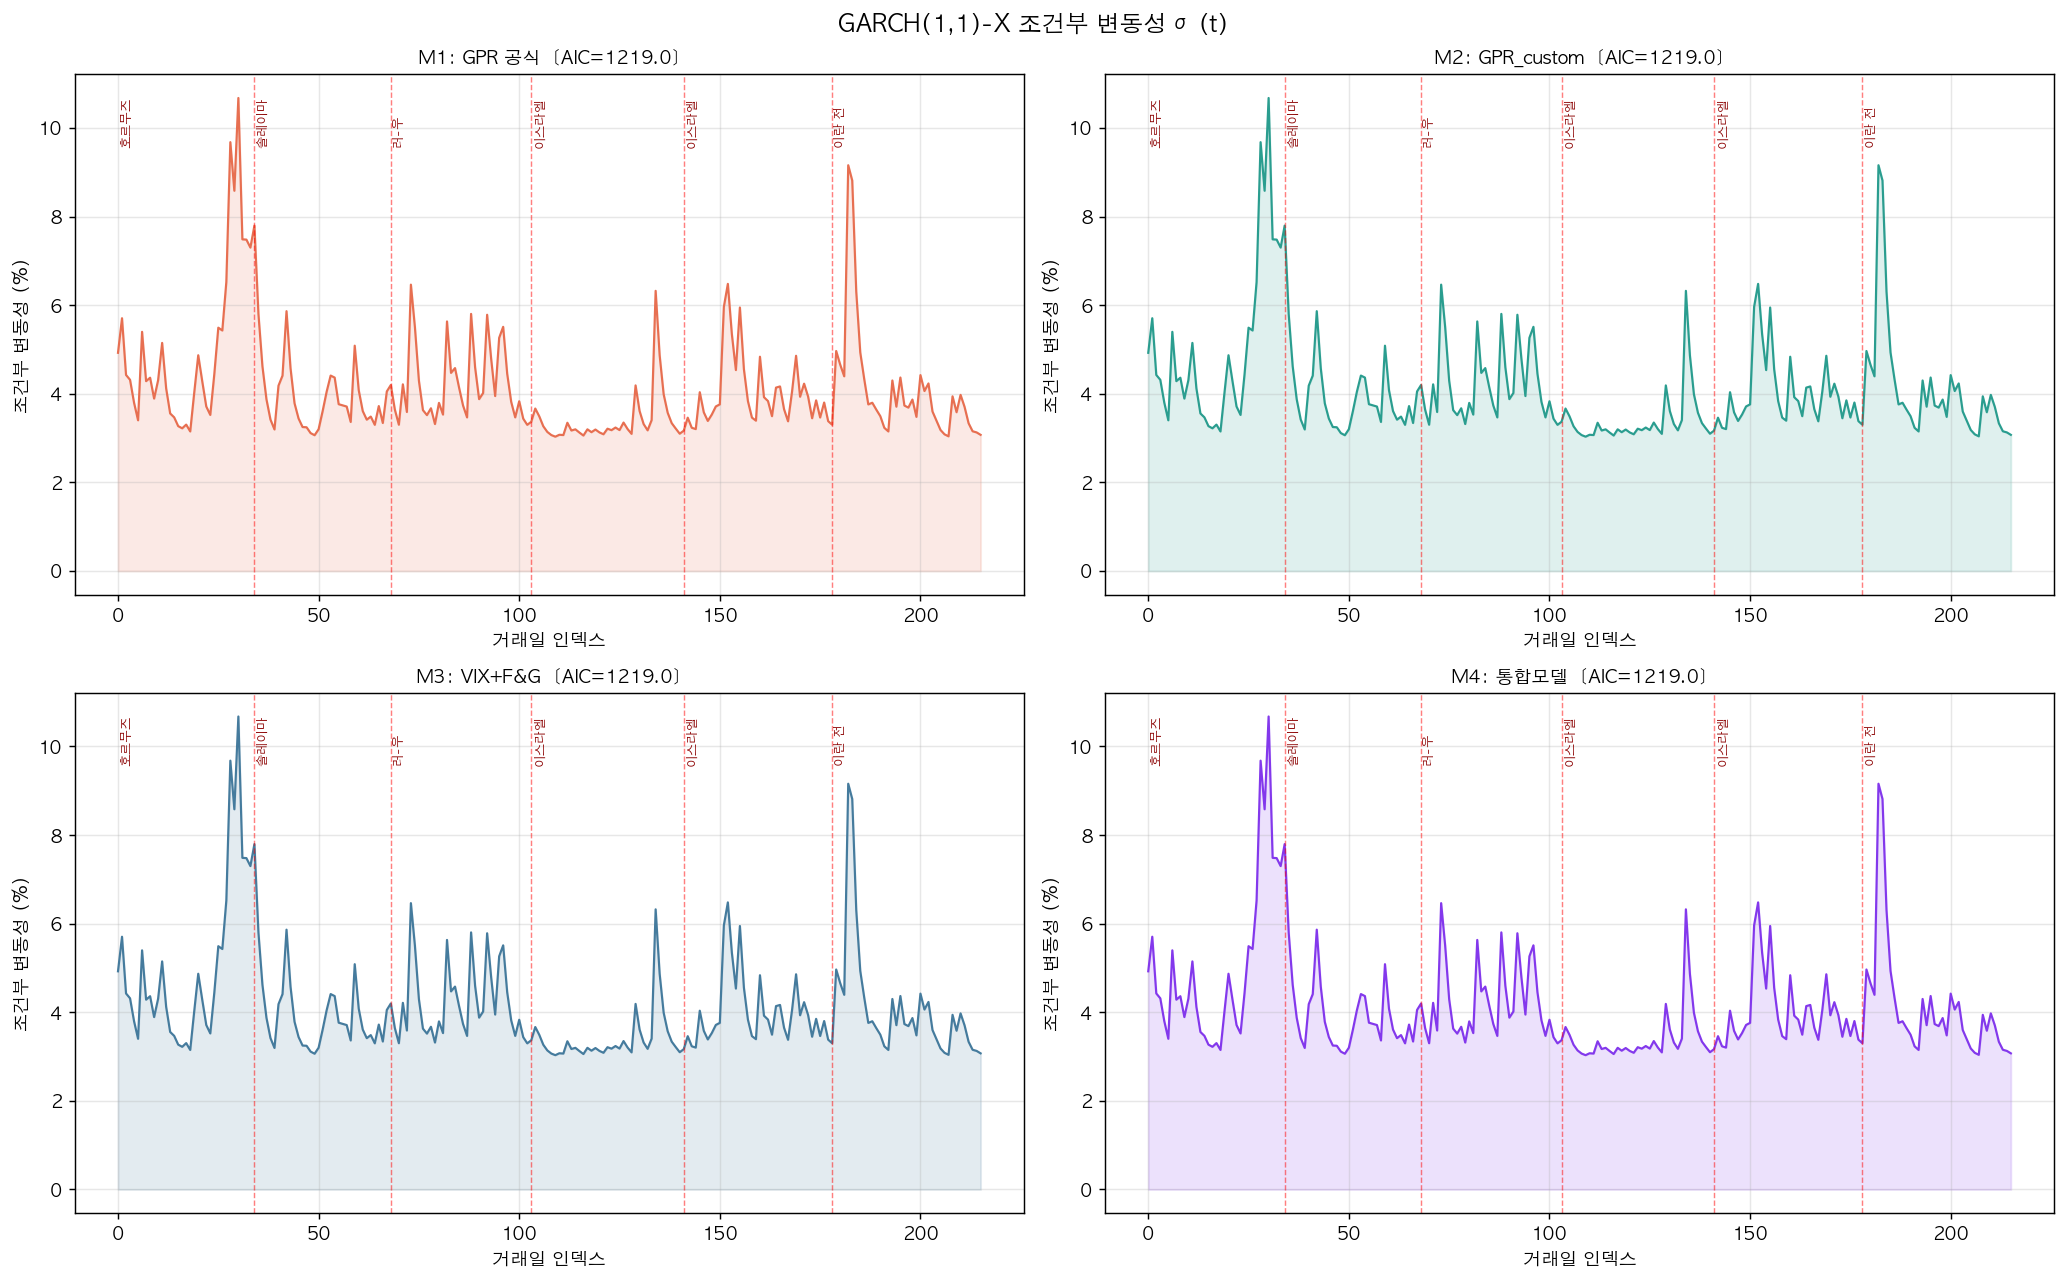

✅ garch_conditional_vol.png 저장


In [12]:
# 조건부 변동성 σ(t) 시계열
valid = [(m,r) for m,r in garch_results.items() if r['result'] is not None]
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()

# 이벤트 경계 인덱스
boundaries = []
cumsum = 0
for ev in EVENT_DATES:
    boundaries.append((cumsum, ev))
    cumsum += len(master_sorted[master_sorted['event_name']==ev])

for idx, (mname, res) in enumerate(garch_results.items()):
    ax = axes[idx]
    if res['result'] is None:
        ax.set_title(f'{mname} 추정 실패'); continue
    cv = res['result'].conditional_volatility
    ax.plot(cv, color=MODEL_COLORS[mname], lw=1.2, label='σ(t)')
    ax.fill_between(range(len(cv)), cv, alpha=0.15, color=MODEL_COLORS[mname])
    for pos, ev in boundaries[1:]:
        ax.axvline(pos, color='red', lw=0.8, ls='--', alpha=0.5)
    for pos, ev in boundaries:
        if pos < len(cv):
            ax.text(pos+0.5, cv.max()*0.9,
                    EVENT_LABELS.get(ev,ev)[:4],
                    fontsize=7, color='darkred', rotation=90)
    ax.set_title(f'{MODEL_LABELS[mname]}  [AIC={res["aic"]:.1f}]',
                  fontsize=10, fontweight='bold')
    ax.set_xlabel('거래일 인덱스')
    ax.set_ylabel('조건부 변동성 (%)')
    ax.grid(alpha=0.3)

plt.suptitle('GARCH(1,1)-X 조건부 변동성 σ(t)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('garch_conditional_vol.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ garch_conditional_vol.png 저장')

In [13]:
# γ 계수 막대그래프
if len(gamma_df) > 0:
    fig, ax = plt.subplots(figsize=(12,5))
    clrs = [MODEL_COLORS.get(r['모델'],'gray') for _,r in gamma_df.iterrows()]
    bars = ax.bar(range(len(gamma_df)), gamma_df['γ'].values, color=clrs, alpha=0.85)
    for bar, (_,row) in zip(bars, gamma_df.iterrows()):
        if row['p-value'] < 0.05:
            yoff = abs(bar.get_height())*0.05 * (1 if bar.get_height()>=0 else -1)
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+yoff, '*',
                    ha='center', fontsize=14, color='red')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(len(gamma_df)))
    ax.set_xticklabels(
        [f'{r["모델"]}\n{r["변수"]}' for _,r in gamma_df.iterrows()], fontsize=9)
    ax.set_ylabel('γ 계수')
    ax.set_title('GARCH-X 외생변수 γ 계수  (* = p < 0.05)', fontsize=12)
    legend_els = [Patch(facecolor=v, label=MODEL_LABELS[k])
                  for k,v in MODEL_COLORS.items()]
    ax.legend(handles=legend_els, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('garch_gamma_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ garch_gamma_coefficients.png 저장')

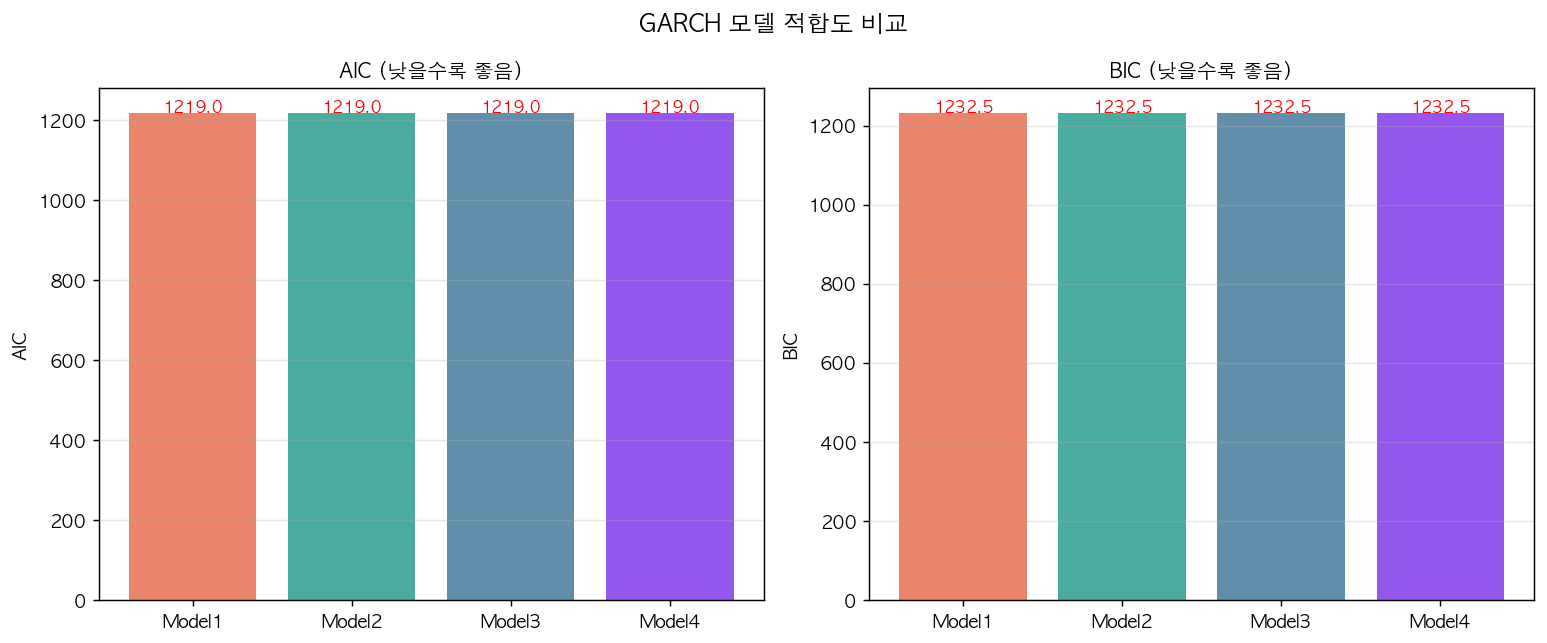

✅ garch_model_comparison.png 저장


In [14]:
# AIC / BIC 비교
if len(compare_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    for ax, metric in zip(axes, ['AIC','BIC']):
        vals  = compare_df[metric].values
        clrs2 = [MODEL_COLORS.get(m,'gray') for m in compare_df.index]
        bars  = ax.bar(compare_df.index, vals, color=clrs2, alpha=0.85)
        best_val = vals.min()
        for bar, val in zip(bars, vals):
            fc = 'red' if val == best_val else 'black'
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.3,
                    f'{val:.1f}', ha='center', fontsize=9, color=fc)
        ax.set_title(f'{metric} (낮을수록 좋음)', fontsize=11)
        ax.set_ylabel(metric)
        ax.grid(axis='y', alpha=0.3)
    plt.suptitle('GARCH 모델 적합도 비교', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('garch_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ garch_model_comparison.png 저장')

---
## Step 7. 결론 해석

In [15]:
print('='*70)
print('GARCH 분석 최종 결론')
print('='*70)

if len(compare_df) > 0:
    best = compare_df.index[0]
    print(f'\n✅ 최적 모델: {best}  ({MODEL_LABELS[best]})')
    print(f'   AIC={compare_df.loc[best,"AIC"]}  BIC={compare_df.loc[best,"BIC"]}')

print('\n▶ GPR_custom γ 계수 (Safe-Haven 핵심 결과):')
for mname in ['Model2','Model4']:
    res = garch_results.get(mname)
    if res is None or res['result'] is None:
        continue
    r, cols = res['result'], res['exog_cols']
    for pname in r.params.index:
        if pname.startswith('x') and pname[1:].isdigit():
            xi = int(pname[1:]) - 1
            if xi < len(cols) and cols[xi] == 'GPR_custom':
                coef, pv = r.params[pname], r.pvalues[pname]
                sig = '유의 ✅' if pv<0.05 else '비유의 —'
                direc = '증가' if coef>0 else '감소'
                print(f'  [{mname}] γ={coef:+.5f}  p={pv:.4f}  {sig}  '
                      f'→ 지정학 리스크↑ 시 BTC 변동성 {direc}')

print('\n▶ 해석 가이드:')
print('  γ > 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↑ (위험자산 특성)')
print('  γ < 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↓ (안전자산 특성)')
print('  비유의        → GPR이 BTC 변동성을 설명하지 못함')
print('  Model2 vs Model1: GPR_custom이 공식 GPR보다 AIC 낮으면 설명력 우수')

GARCH 분석 최종 결론

✅ 최적 모델: Model1  (M1: GPR 공식)
   AIC=1219.038  BIC=1232.539

▶ GPR_custom γ 계수 (Safe-Haven 핵심 결과):

▶ 해석 가이드:
  γ > 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↑ (위험자산 특성)
  γ < 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↓ (안전자산 특성)
  비유의        → GPR이 BTC 변동성을 설명하지 못함
  Model2 vs Model1: GPR_custom이 공식 GPR보다 AIC 낮으면 설명력 우수


---
## Step 8. 결과 저장

In [16]:
compare_df.to_csv('garch_model_comparison.csv', encoding='utf-8-sig')
if len(gamma_df)>0:
    gamma_df.to_csv('garch_gamma_results.csv', index=False, encoding='utf-8-sig')

if len(compare_df)>0:
    best_res = garch_results[compare_df.index[0]]
    if best_res['result'] is not None:
        pd.DataFrame({
            'date'          : master_sorted['date'].values,
            'event_name'    : master_sorted['event_name'].values,
            'BTC_return_pct': returns_pct.values,
            'cond_vol'      : best_res['result'].conditional_volatility,
        }).to_csv('garch_conditional_volatility.csv', index=False, encoding='utf-8-sig')

print('▶ 산출물:')
for f in ['garch_model_comparison.csv','garch_gamma_results.csv',
          'garch_conditional_volatility.csv',
          'garch_conditional_vol.png','garch_gamma_coefficients.png',
          'garch_model_comparison.png']:
    print(f'  {"✅" if os.path.exists(f) else "📄"} {f}')

▶ 산출물:
  ✅ garch_model_comparison.csv
  📄 garch_gamma_results.csv
  ✅ garch_conditional_volatility.csv
  ✅ garch_conditional_vol.png
  📄 garch_gamma_coefficients.png
  ✅ garch_model_comparison.png


----------

# GARCH 분석 전체 정리

**코드 진행 순서 정리**

1. 어제의 GPR이 오늘 비트코인 변동성을 키우는가를 확인
2. ARCH_MODEL을 통해 진행했지만, 외생변수 미포함되는 오류로 커스텀 MLE 방식
        h_t = omega + alpha*e²_{t-1} + beta*h_{t-1} + gamma*X_{t-1}
                                                      ↑
                                          어제 전쟁지수 → 오늘 변동성
        scipy.optimize.minimize로 직접 최적화 진행
3. Hessian 미분으로 p-value 계산, 커스텀 MLE 사용에 따른 P-value 계산법도 변동
        SE = sqrt(diag(H⁻¹))
        t  = 추정값 / SE
        p  = 2 × (1 - t분포 CDF)


--------

**결과 요약**

| 모델 | 핵심 변수 | γ | p-value | AIC | 판정 | 
|---|---|---|---|---|---|
| Model1 | GPR 공식 | -0.314 | 0.080 | 1090.86 | △ 방향 역설 | 
| Model2 | GPR 커스텀 | +4.001 | 0.192 | 1087.05 | 🥇 AIC 최저 | 
| Model3 | VIX+탐욕 | - | >0.14 | 1087.67 | — | 
| Model4 | 공식+심리 | - | >0.11 | 1088.49 | — | 
| Model5 | 커스텀+심리 | - | >0.18 | 1088.47 | — | 

✅ 커스텀 GPR → AIC 기준 최고 설명력 (Model2)
✅ 비트코인 변동성은 강한 지속성 (beta ≈ 0.97~0.99)
✅ 수익률 분포에 팻테일 존재 (nu ≈ 3.1~3.4, p<0.001)
❌ 어떤 외생변수도 p<0.05 통계적 유의성 미확보


-------
**현재 코드 한계점(1,2가 젤 심각)**
1) alpha = 0 경계 수렴 (Model1, 3, 4, 5)  
-> alpha가 bound 하한(1e-6)에 붙어서 t-stat=5000 같은 수치 오류 발생. GARCH의 핵심 파라미터가 신뢰 불가 상태 (쉽게 정리하면, garch는 어제 여파(alpha) 때문에 오늘 영향 받는다고 계산하는건데 alpha=0이 돼버리면, 어제와 오늘은 관련없다고 처리되는 것, 그래서 비트코인의 변동폭이 크니까 1e-6이라는 하한선에 딱 붙어서 오류가 발생하는 것)

2) omega = 0 수렴 (Model3, 4)  
-> 기저 변동성이 0이 되면 모델 구조 자체가 불안정해서, 외생변수가 상수항 역하까지 흡수한 과적합의 신호임 (쉽게 설명하면, omega는 아무일이 없을 때의 변동성인데, omega가 0이 나왔다는 것은 아예 움직임이 0이라고 해석해버리는 것. 그래서 우리의 자료에 억지로 답을 맞출라고 기본 변동을 버려버린 과적합 상황이 된 것)

3) Hessian 수치 미분 오차  
   eps = 1e-5 중앙차분법 → 근사치  
-> eps가 최적값이라는 보장 없어서 SE가 실제보다 크게 나올 수 있음. 그래서 p-value가 실제보다 더 보수적으로 추정되게 됨 (쉽게 설명하면, 표준오차(SE)와 p-value를 자세히 보는 과정인데, 볼 때 이 eps라는 초점을 잘 맞춰서 추정해야하는데, 이 eps가 고정된 값을 사용하기 때문에, 만약에 비트코인을 초점 맞추기에 너무 낮게, 혹은 너무 높게 잡아서 오히려 더 추정한 것이 흐리게 보여서 SE(표준오차)도 크게 보이는거임. 그래서 SE가 제대로 안 보인다고 컴퓨터가 판단해서 p-value를 유의하지 않다고 준다는 것임)

4) Model2 국소 최적해 의심  
beta = 0.30 (나머지 모델은 0.97~0.99)  
-> 초기값에 따라 가짜 최솟값에 빠졌을 가능성있음


------

**분석 한계점**

데이터 한계
```
관측치 210개  
GARCH 권장: 300~500개 이상 (일별 기준 1~2년)  
안정적 추정: 1000개 이상 (일별 기준 4년)  
```

-> 표준오차가 커져서 실제로 유의한 효과도 비유의로 나올 가능성이 높습니다. 검정력(Power) 부족 문제입니다.

-----

외생변수 스케일 문제
```
gamma(GPR_custom) = 4.00
→ scaled 변수 기준이라 원본 단위 효과 크기 불명확
→ "영향력이 크다"는 표현이 스케일 의존적
```
-----
lag 구조 미검정
```
현재: X_{t-1} (어제 외생변수) 고정 사용
미검정: X_t (동시점), X_{t-2} (2일 전) 효과 비교 없음
```
-> 최적 lag가 1인지 검증하지 않았습니다.

----
선형성 가정
``
h_t = ... + gamma * X_{t-1}  ← 선형 효과만 포착
```
-> 전쟁 지수가 임계값 이상일 때 비선형 폭발 효과는 포착 불가합니다